# Logistic Regression is a classification algorithm that models the probability of a categorical outcome 
# — most often a binary outcome (like Yes/No, 0/1, Pass/Fail).

# logistic regression predicts the probability that an observation belongs to a certain class.
# It uses the logistic (sigmoid) function to map predictions into the range [0,1]

# Types:--
# Binary Logistic Regression → Two outcomes (e.g., churn vs no churn).
# Multinomial Logistic Regression → More than two unordered outcomes (e.g., choosing between car/bike/bus).
# Ordinal Logistic Regression → Ordered categories (e.g., low/medium/high satisfaction).

# Logistic regression is widely used in business (churn prediction), medicine (disease diagnosis), and social sciences (survey outcomes).

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd

week_data = [1, 2, 3, 4, 5]
sales_data = [2, 4, 5, 4, 5]

df = pd.DataFrame({"Weeks": week_data, "Sales": sales_data})
print(df)

   Weeks  Sales
0      1      2
1      2      4
2      3      5
3      4      4
4      5      5


In [4]:
X = df["Weeks"].values
print(X)
Y = df["Sales"].values
print(Y)

[1 2 3 4 5]
[2 4 5 4 5]


In [5]:
mean_x = np.mean(X)
mean_y = np.mean(Y)
print(mean_x)
print(mean_y)

n = len(X)
num = 0
den = 0

for i in range(n):
    num += (X[i] - mean_x) * (Y[i] - mean_y)
    den += (X[i] - mean_x) ** 2

m = num/den
print("Slope :" , m)

c = mean_y - (m * mean_x)
print("Intercept :" , c)

3.0
4.0
Slope : 0.6
Intercept : 2.2


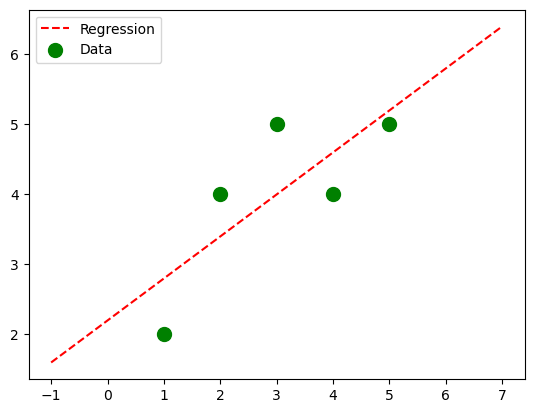

In [6]:
max_x = np.max(X) + 2
min_x = np.min(X) - 2

x = np.linspace(min_x, max_x)
y = m * x + c

# Line plot
plt.plot(x, y, label ='Regression' , color = "Red", linestyle = '--')
plt.scatter(X,Y, color = 'green', label = "Data", s =100)
plt.legend(loc = 'best')
plt.show()

In [7]:
# R Sqaure Value

ss_residual = 0
ss_total = 0

for i in range(n):
    y_pred = (m *X[i]) + c
    ss_total += (Y[i] - mean_y) ** 2
    ss_residual += (Y[i] - y_pred) ** 2
r2 = 1 - (ss_residual/ss_total)
print(r2)

0.6000000000000001


In [8]:
# RMSE value
rmse = 0

for i in range(n):
    y_pred = (m *X[i]) + c
    rmse += (Y[i] - y_pred) ** 2

rmse = np.sqrt(rmse/n)
print(rmse)

0.6928203230275508


In [9]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [11]:
X = X.reshape((n,1))
print(X)

[[1]
 [2]
 [3]
 [4]
 [5]]


In [12]:
reg = LinearRegression()
reg.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = reg.predict(X)
mse = mean_squared_error(Y, y_pred)
r2_score = reg.score(X, Y)
print(r2_score)
print(np.sqrt(mse))

0.6000000000000001
0.6928203230275508


In [14]:
import pandas as pd

data = pd.read_csv("headbrain.csv")
data.head(4)

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282


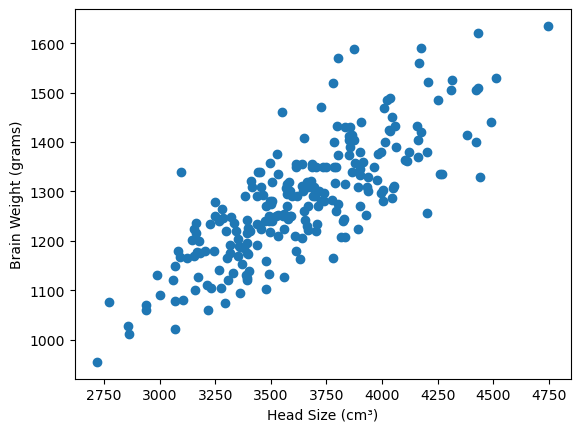

In [15]:
import matplotlib.pyplot as plt

X = data['Head Size(cm^3)']
Y = data['Brain Weight(grams)']
plt.scatter(X, Y)
plt.xlabel("Head Size (cm³)")
plt.ylabel("Brain Weight (grams)")
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = pd.read_csv("headbrain.csv")

X = data['Head Size(cm^3)'].values.reshape(-1, 1)
Y = data['Brain Weight(grams)'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=1234)

# Fit model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 6652.84023917658
RMSE: 81.56494491616223
R² Score: 0.5628129351789338


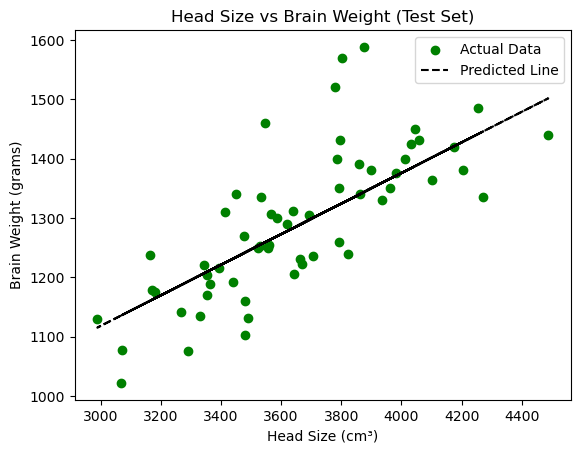

In [17]:
import matplotlib.pyplot as plt

# Scatter plot of actual test data
plt.scatter(X_test, y_test, color='green', label='Actual Data')

# Plot regression line (use plt.plot, not scatter)
plt.plot(X_test, y_pred, color='black', linestyle='--', label='Predicted Line')

plt.xlabel("Head Size (cm³)")
plt.ylabel("Brain Weight (grams)")
plt.title("Head Size vs Brain Weight (Test Set)")
plt.legend(loc='best')
plt.show()

In [18]:
# The AUC-ROC curve is a performance metric for binary classification problems, representing the trade of 
# between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity) across different threshold levels. 
# It measures how well a model separates positive and negative classes, with an AUC of 1.0 indicating perfect classification 
# and 0.5 suggesting random guessing.

# ROC Curve (Receiver Operating Characteristic): Plots the True Positive Rate (TPR) on the y-axis 
# against the False Positive Rate (FPR) on the x-axis at various threshold settings.
# AUC (Area Under the Curve): A single number summary of the ROC curve, representing the probability that a model 
# ranks a random positive example higher than a random negative one.

# Interpretation:
# 0.5: No better than random chance.
# 0.7 - 0.8: Acceptable performance.
# 0.8 - 0.9: Excellent performance.
# > 0.9: Outstanding performance.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("HR_comma_sep.csv")
df.head(5)
df.shape

(14999, 10)

In [21]:
# Attrition Analysis

left = df[df.left == 1] 
print(left.shape)

(3571, 10)


In [22]:
retained = df[df.left == 0]
print(retained.shape)

(11428, 10)


In [23]:
# Attrition Rate is 23% (left the oragnization)
3571/14999 * 100

23.80825388359224

In [24]:
# Group by the 'left' column and compute mean of all numeric columns
group_means = df.groupby("left").mean(numeric_only=True)
print(group_means)

# based on analysis we found that:--
# -- satisfaction_level is less
# -- average_monthly_hours is more
# -- time_spend_company is more
# -- promotion_last_5years is minimum

      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


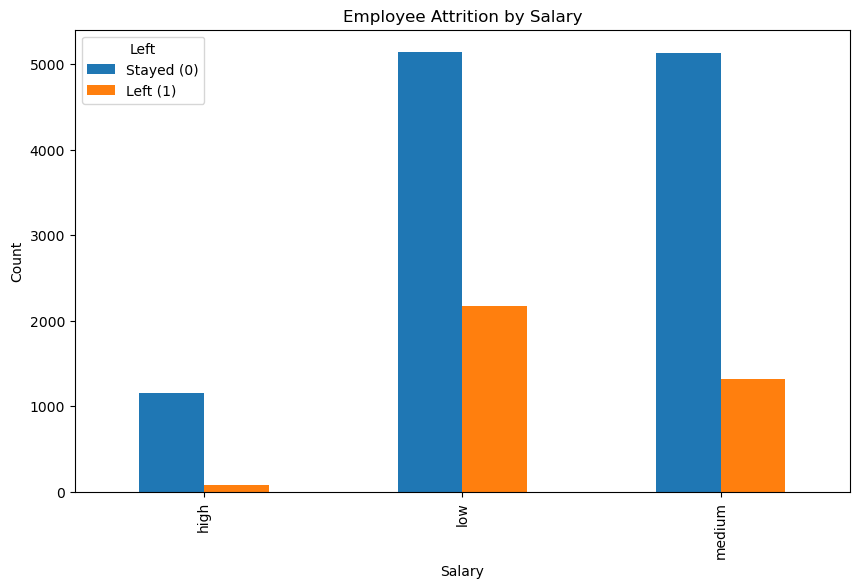

In [25]:
# Impact of salary on retention findings
import pandas as pd
import matplotlib.pyplot as plt

# Example: assuming df has columns 'salary' and 'left'
ct = pd.crosstab(df['salary'], df['left'])

# Plot as bar chart
ct.plot(kind='bar', figsize=(10,6))
plt.xlabel("Salary")
plt.ylabel("Count")
plt.title("Employee Attrition by Salary")
plt.legend(title="Left", labels=["Stayed (0)", "Left (1)"])
plt.show()

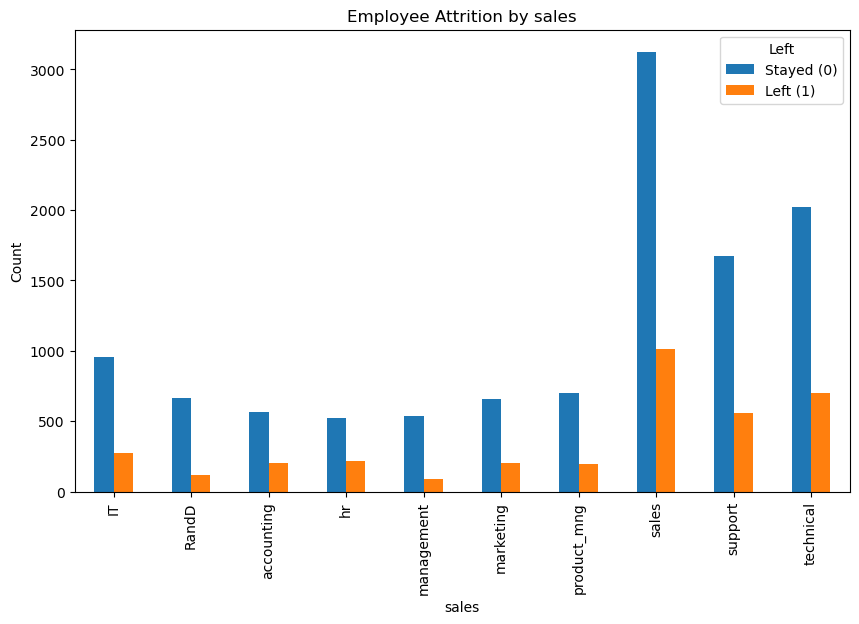

In [26]:
# Analysing people who left are from which department mostly
import pandas as pd
import matplotlib.pyplot as plt

# Example: assuming df has columns 'salary' and 'left'
ct = pd.crosstab(df['sales'], df['left'])

# Plot as bar chart
ct.plot(kind='bar', figsize=(10,6))
plt.xlabel("sales")
plt.ylabel("Count")
plt.title("Employee Attrition by sales")
plt.legend(title="Left", labels=["Stayed (0)", "Left (1)"])
plt.show()

In [27]:
# Creating another DataFrame based on columns (X) THAT EFFECT the left column (Y)

subdf = df[['satisfaction_level', 'satisfaction_level', 'promotion_last_5years' , 'salary']]
subdf.head(5)

,satisfaction_level,satisfaction_level,promotion_last_5years,salary
0,0.38,0.38,0,low
1,0.80,0.80,0,medium
2,0.11,0.11,0,medium
3,0.72,0.72,0,low
4,0.37,0.37,0,low


In [28]:
# Using encoding techniques on salary column as it is contains string and we have to convert it to numeric
# We will use one-hot encoding technique (dummy encoding) in this case

salary_dummies = pd.get_dummies(subdf.salary, prefix = 'salary')

In [29]:
# Concatenate original subset with dummy variables
df_with_dummies = pd.concat([subdf, salary_dummies], axis=1)

print(df_with_dummies.head())

   satisfaction_level  satisfaction_level  promotion_last_5years  salary  \
0                0.38                0.38                      0     low   
1                0.80                0.80                      0  medium   
2                0.11                0.11                      0  medium   
3                0.72                0.72                      0     low   
4                0.37                0.37                      0     low   

   salary_high  salary_low  salary_medium  
0        False        True          False  
1        False       False           True  
2        False       False           True  
3        False        True          False  
4        False        True          False  


In [30]:
# Drop the salary column from the dataframe
df_with_dummies.drop(columns=['salary'], inplace=True)

In [31]:
df_with_dummies.head(5)

,satisfaction_level,satisfaction_level,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,0.38,0,False,True,False
1,0.80,0.80,0,False,False,True
2,0.11,0.11,0,False,False,True
3,0.72,0.72,0,False,True,False
4,0.37,0.37,0,False,True,False


Log Loss: 0.5415269931379109
Accuracy: 0.7634666666666666
Confusion Matrix:
 [[2136  717]
 [ 170  727]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83      2853
           1       0.50      0.81      0.62       897

    accuracy                           0.76      3750
   macro avg       0.71      0.78      0.72      3750
weighted avg       0.83      0.76      0.78      3750



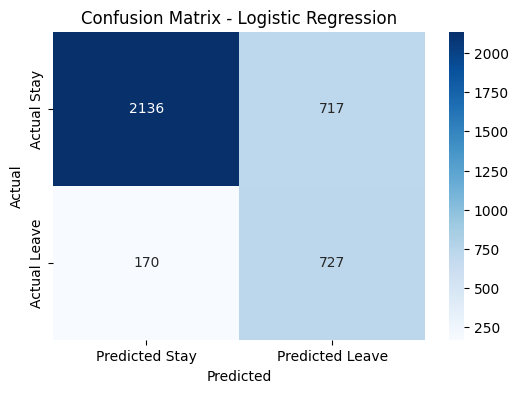

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, log_loss, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("HR_comma_sep.csv")

# 2. Encode categorical variables (example: 'salary', 'department')
df = pd.get_dummies(df, drop_first=True)

# 3. Define features and target
X = df.drop(columns=['left'])   # predictors
y = df['left']                  # target (0 = stayed, 1 = left)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 5. Logistic Regression model
model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Predicted probabilities
y_prob = model.predict_proba(X_test)

# Calculate Loss Function

loss = log_loss(y_test, y_prob)
print("Log Loss:", loss)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 9. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 10. Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay','Predicted Leave'],
            yticklabels=['Actual Stay','Actual Leave'])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

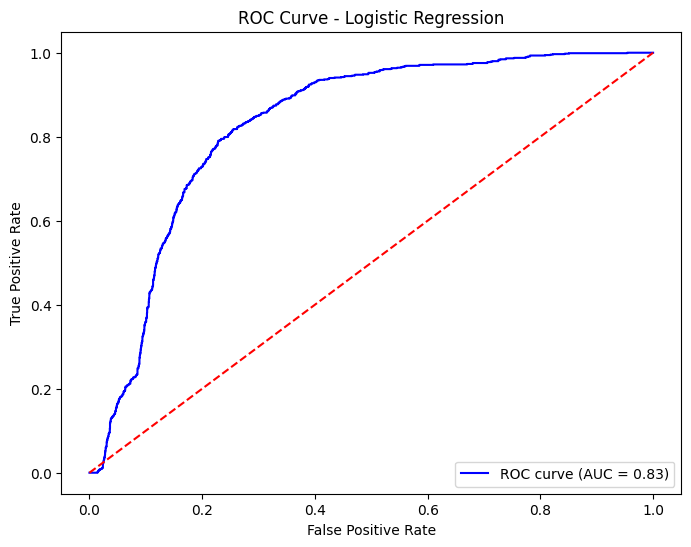

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]


# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

Before SMOTE
left
0    8571
1    2678
Name: count, dtype: int64

After SMOTE
left
0    8571
1    8571
Name: count, dtype: int64
Log Loss: 0.518
Accuracy: 0.7701

Confusion Matrix:

[[2237  620]
 [ 242  651]]

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.84      2857
           1       0.51      0.73      0.60       893

    accuracy                           0.77      3750
   macro avg       0.71      0.76      0.72      3750
weighted avg       0.81      0.77      0.78      3750



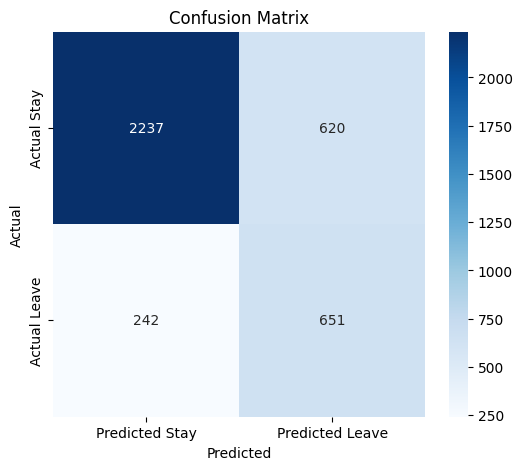

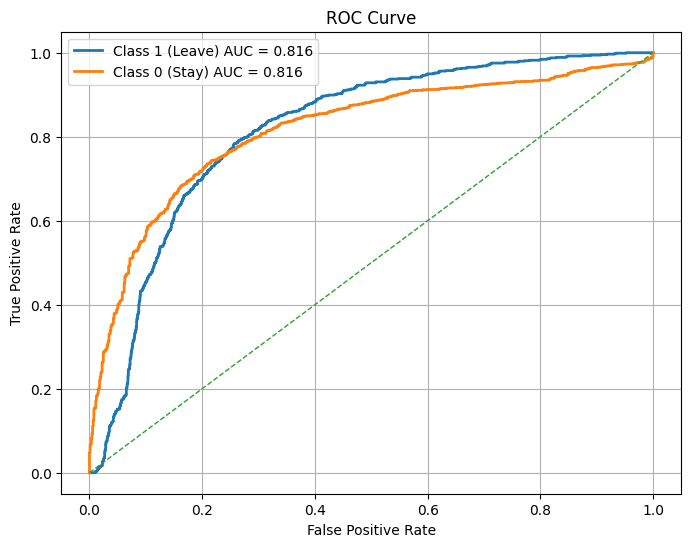


ROC-AUC Score (Class 1): 0.816
ROC-AUC Score (Class 0): 0.816


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    log_loss,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

# --------------------------
# 1. Load dataset
# --------------------------

df = pd.read_csv("HR_comma_sep.csv")

# --------------------------
# 2. Encode categorical variables
# --------------------------

df = pd.get_dummies(df, drop_first=True)

# --------------------------
# 3. Define features and target
# --------------------------

X = df.drop(columns=['left'])
y = df['left']

# --------------------------
# 4. Train-test split
# --------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# --------------------------
# 5. Apply SMOTE ONLY on training data
# --------------------------

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

# --------------------------
# 6. Logistic Regression
# --------------------------

model = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

model.fit(X_train_smote, y_train_smote)

# --------------------------
# 7. Predictions
# --------------------------

y_pred = model.predict(X_test)

# Probability of both classes
y_prob = model.predict_proba(X_test)

# Probability of class 1
y_prob_class1 = y_prob[:,1]

# --------------------------
# 8. Log Loss
# --------------------------

loss = log_loss(y_test, y_prob)

print("Log Loss:", round(loss,4))

# --------------------------
# 9. Accuracy
# --------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))

# --------------------------
# 10. Confusion Matrix
# --------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# --------------------------
# 11. Classification Report
# --------------------------

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# --------------------------
# 12. Confusion Matrix Graph
# --------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Stay','Predicted Leave'],
    yticklabels=['Actual Stay','Actual Leave']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# --------------------------
# 13. ROC Curve - Class 1
# --------------------------

fpr1, tpr1, _ = roc_curve(
    y_test,
    y_prob_class1
)

auc1 = roc_auc_score(
    y_test,
    y_prob_class1
)

# --------------------------
# 14. ROC Curve - Class 0
# --------------------------

fpr0, tpr0, _ = roc_curve(
    1 - y_test,
    y_prob[:,0]
)

auc0 = roc_auc_score(
    1 - y_test,
    y_prob[:,0]
)

# --------------------------
# 15. Plot ROC Curves
# --------------------------

plt.figure(figsize=(8,6))

plt.plot(
    fpr1,
    tpr1,
    linewidth=2,
    label=f'Class 1 (Leave) AUC = {auc1:.3f}'
)

plt.plot(
    fpr0,
    tpr0,
    linewidth=2,
    label=f'Class 0 (Stay) AUC = {auc0:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# --------------------------
# 16. Overall ROC-AUC
# --------------------------

print("\nROC-AUC Score (Class 1):", round(auc1,4))

print("ROC-AUC Score (Class 0):", round(auc0,4))